# Gradient Descent

According to Wikipedia, "In mathematics, gradient descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function". It is a machine learning algorithm that operates iteratively to find the optimal values for its parameters which are then fed to the machine learning model to build a model which predicts a value with minimal error. 


The gradient descent algorithm is given below -


1.   Choose a starting point or the initialization of values
2.   Calculate the gradient at this point
3.   Make a scaled step in the opposite direction to the gradient in order to minimize it
4.   Repeat until a gradient tolerance or iteration budget is reached; convergence is not guaranteed for arbitrary steps.



The mathematical formula for this algorithm is given by-

\begin{align}
    w_{n+1} = w_n - \alpha g'(w_n)
  \end{align}

where $w_n$ is the parameter at iteration $n$, $\alpha$ is the step size, and $g$ is the objective.

We use the NumPy-compatible [HIPS autograd](https://github.com/HIPS/autograd) package, not PyTorch. Its `grad` function constructs the derivative of a scalar objective.

Given the following function

\begin{align}
    g(x)= x^2 + 3x + 2 
  \end{align}

We can Calculate the value of the gradient at x = 30.

In [1]:
# Install requirements.txt before starting this notebook.
from autograd import grad
import autograd.numpy as np

def implement_g(x):
    return x**2 + 3*x + 2
    
def try_autograd(x):
    # We pass the function g(x) as an input to this grad function from autograd
    gradient = grad(implement_g)
    ans = gradient(x)
    return ans

print("Gradient of g(x)=x^2+3x+2 at x=30:", try_autograd(30.0))

Gradient of g(x)=x^2+3x+2 at x=30: 63.0


Now that we know how to calculate the gradient, we will implement the gradient descent algorithm for a given set of values.

Let the learning rate or alpha be 0.5 and the number of iterations be 100. We Calculate the parameter value at every step of the iteration and store them in an array and return the array. We Use the autograd function as before to calculate the gradient of the given function. 

\begin{align}
    g(x) = (x-2)^2
  \end{align}

Let the initial parameter be $w_0 = 1.75$.

In [2]:
def implement_new_g(x):
    return (x-2)**2
    
def gradient_descent(g, w0, alpha, n):
    parameter_history = []
    w = w0
    grad_g = grad(g)
    
    for i in range(n):
        parameter_history.append(w)
        w = w - alpha * grad_g(w)

    return parameter_history

param_hist = gradient_descent(implement_new_g, 1.75, 0.5, 100)
print("gradient Descent Parameter History:\n", param_hist)

gradient Descent Parameter History:
 [1.75, np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.f

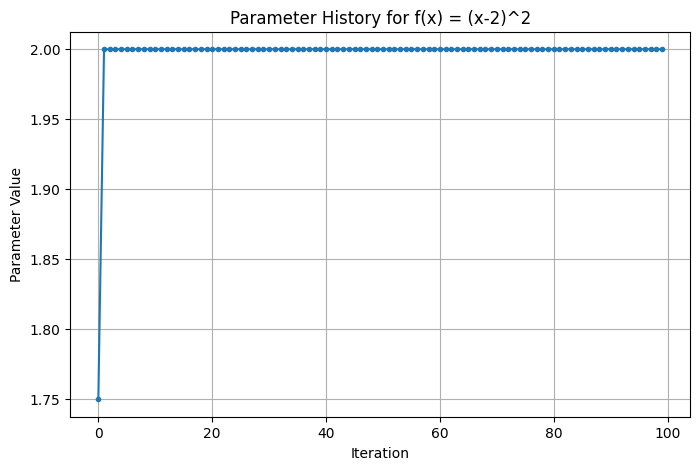

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(param_hist, marker='o', markersize=3)
plt.title("Parameter History for f(x) = (x-2)^2")
plt.xlabel("Iteration")
plt.ylabel("Parameter Value")
plt.grid(True)
plt.show()

We will now do 2 runs

*Run 1*: \\
g = square root of (x* x* x)

w = 1.0

max_its=100

alpha=0.1

*Run 2*: \\
g = square root of (x*x)

w = 1.5

max_its=100

alpha=0.01

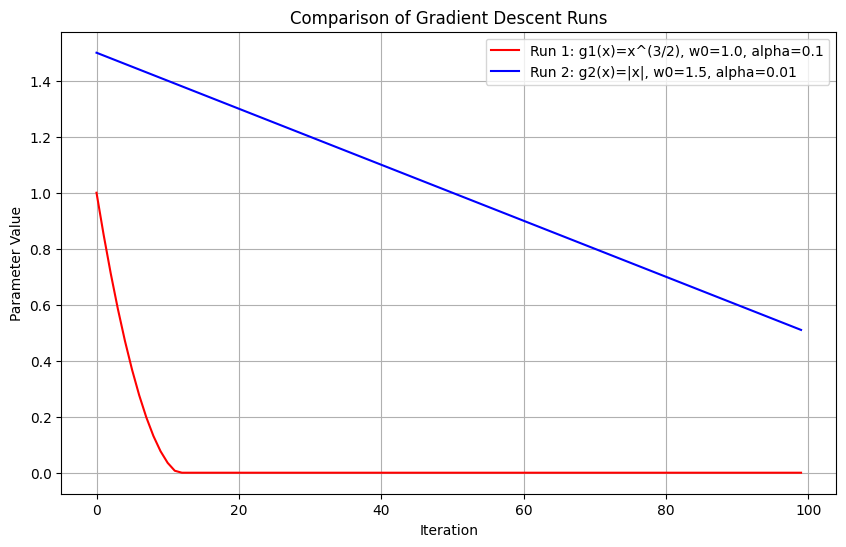

In [4]:
# x^(3/2) is constrained to x >= 0; project steps back into its domain.
def implement_g1(x):
    return x**1.5

def implement_g2(x):
    return np.abs(x)

def run_gradient_descent(g, w0, alpha, n, project=lambda x: x):
    history = []
    w=w0
    grad_func = grad(g)
    for i in range(n):
        history.append(w)
        w = project(w - alpha * grad_func(w))
    return history

w0_run1 = 1.0
alpha_run1 = 0.1
its_run1 = 100
history1 = run_gradient_descent(implement_g1, w0_run1, alpha_run1, its_run1, project=lambda x: max(0.0, x))

w0_run2 = 1.5
alpha_run2 = 0.01
its_run2 = 100
history2 = run_gradient_descent(implement_g2, w0_run2, alpha_run2, its_run2)

plt.figure(figsize=(10, 6))
plt.plot(history1, color='red', label='Run 1: g1(x)=x^(3/2), w0=1.0, alpha=0.1')
plt.plot(history2, color='blue', label='Run 2: g2(x)=|x|, w0=1.5, alpha=0.01')
plt.title("Comparison of Gradient Descent Runs")
plt.xlabel("Iteration")
plt.ylabel("Parameter Value")
plt.legend()
plt.grid(True)
plt.show()